In [1]:
# Instalar YOLOv8
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:0000:01


In [ ]:

from ultralytics import YOLO
print("YOLO listo v")



YOLO listo v


In [4]:
# Instalamos la librería de Kaggle para poder descargar datasets
# Kaggle requiere autenticación para descargar datos
!pip install kaggle

In [ ]:
# Subimos el archivo kaggle.json al entorno de Colab
# Esto le da permiso para descargar datasets de Kaggle
import os
os.makedirs('/root/.kaggle', exist_ok=True)

In [7]:
# Montamos Google Drive en el entorno de Colab
# Esto nos da acceso a todos nuestros archivos de Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Cargamos las credenciales desde el .env guardado en Drive
# Así nunca exponemos la key en el código
import os
from dotenv import load_dotenv

# Ruta al .env en tu Drive - ajusta si lo pusiste en otra carpeta
load_dotenv('/content/drive/MyDrive/CAELESTIS/.env')

os.makedirs('/root/.kaggle', exist_ok=True)

import json
kaggle_config = {
    "username": os.getenv("KAGGLE_USERNAME"),
    "key": os.getenv("KAGGLE_KEY")
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Credenciales Kaggle configuradas ✓")
print("Usuario:", os.getenv("KAGGLE_USERNAME"))

Credenciales Kaggle configuradas ✓
Usuario: yessliah


In [9]:
# Descargamos el dataset COSMICA desde Kaggle
# piratinskii es el usuario, astronomical-object-detection es el nombre del dataset
!kaggle datasets download -d piratinskii/astronomical-object-detection --unzip -p /content/cosmica

Dataset URL: https://www.kaggle.com/datasets/piratinskii/astronomical-object-detection
License(s): unknown
100% 1.04G/1.04G [00:08<00:00, 126MB/s] 



In [10]:
# Exploramos la estructura del dataset descargado
# Ver cómo están organizadas las carpetas e imágenes
import os

for root, dirs, files in os.walk('/content/cosmica'):
    level = root.replace('/content/cosmica', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')
            

cosmica/
  yolov11_balanced/
    dataset.yaml
    train/
      images/
      labels/
    valid/
      images/
      labels/
    test/
      images/
      labels/


In [11]:
with open('/content/cosmica/yolov11_balanced/dataset.yaml', 'r') as f:
    print(f.read())

train: train/images
val: valid/images
test: test/images

nc: 4
names: ['comet', 'galaxy', 'globular_cluster', 'nebula']


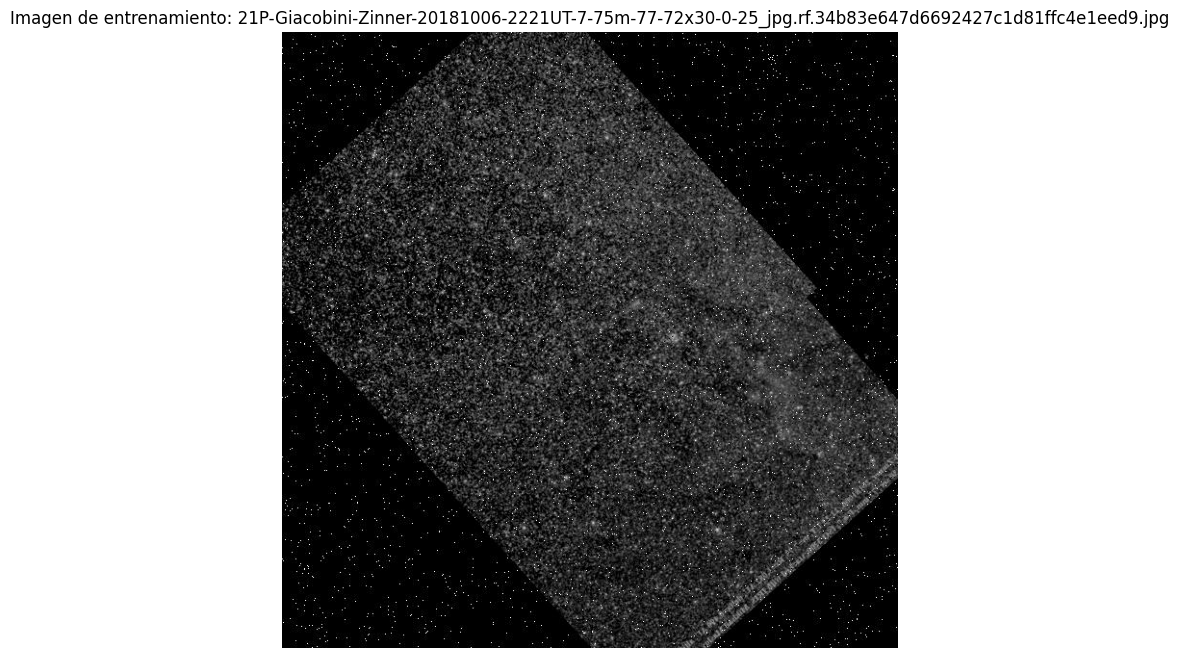

Dimensiones: (640, 640, 3)
Total imágenes entrenamiento: 15589


In [12]:
# Visualizamos una imagen del dataset con sus anotaciones
# Para entender cómo lucen los datos antes de entrenar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Tomamos la primera imagen del conjunto de entrenamiento
train_images = os.listdir('/content/cosmica/yolov11_balanced/train/images')
img_path = f'/content/cosmica/yolov11_balanced/train/images/{train_images[0]}'

img = mpimg.imread(img_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f'Imagen de entrenamiento: {train_images[0]}')
plt.axis('off')
plt.show()

print(f"Dimensiones: {img.shape}")
print(f"Total imágenes entrenamiento: {len(train_images)}")

In [13]:
# FASE IV - Entrenamiento del modelo YOLOv8
# Usamos transfer learning con yolov8n (nano) para empezar
# epochs=50: el modelo verá los datos 50 veces
# imgsz=640: tamaño estándar de imagen para YOLOv8
# batch=16: procesa 16 imágenes a la vez
# project: guarda resultados en tu Drive para no perderlos

from ultralytics import YOLO

# Cargamos desde el checkpoint guardado — NO desde cero
model = YOLO('/content/drive/MyDrive/CAELESTIS/runs/caelestis_v1/weights/last.pt')

results = model.train(
    data='/content/cosmica/yolov11_balanced/dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='caelestis_v1',
    project='/content/drive/MyDrive/CAELESTIS/runs',
    resume=True
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cosmica/yolov11_balanced/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/CAELESTIS/runs/caelestis_v1/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=caelestis_v1, nbs=64, nms=Fal

In [14]:
# Vemos las métricas finales del entrenamiento completo
import pandas as pd

results_df = pd.read_csv('/content/drive/MyDrive/CAELESTIS/runs/caelestis_v1/results.csv')
print(results_df.tail(5))

    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
45     46  2782.19         1.26376         1.09094         1.48493   
46     47  3087.37         1.25499         1.06649         1.47470   
47     48  3396.06         1.24556         1.06713         1.46421   
48     49  3706.38         1.23896         1.04990         1.45752   
49     50  4008.84         1.22902         1.03652         1.45080   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
45               0.78422            0.64531           0.71327   
46               0.78299            0.64706           0.71633   
47               0.79437            0.64825           0.71834   
48               0.79104            0.65138           0.71921   
49               0.79398            0.65038           0.72182   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
45              0.42049       1.43291       1.22205       1.54399  0.003270   
46              0.42292       

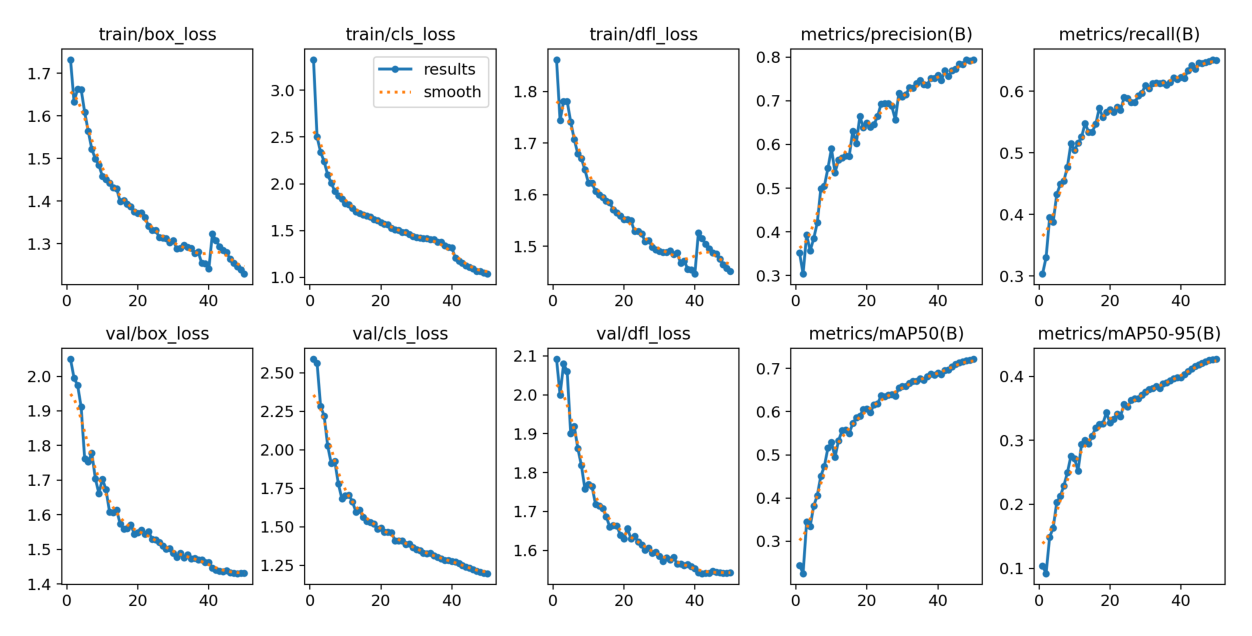

In [15]:
# Visualizamos las curvas de entrenamiento
from ultralytics.utils.plotting import plot_results
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('/content/drive/MyDrive/CAELESTIS/runs/caelestis_v1/results.png')
plt.figure(figsize=(16,8))
plt.imshow(img)
plt.axis('off')
plt.show()